# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [1]:
!pip install langdetect

In [60]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


***

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [68]:
# datos = pd.read_csv('/content/drive/MyDrive/Ciencia de Datos/7. Modelo Hackathon/datos/IMDB Dataset SPANISH.csv')
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/Data-Science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [69]:
datos = datos[['review_es', 'sentimiento']]

In [70]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [71]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [72]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [73]:
datos.sample(10)

,review_es,sentimiento
25017,"En primer lugar, deja que se sepa que entré en...",positivo
28801,BlackAdder 3 es probablemente la serie de Blac...,positivo
11680,"Hay películas malas, películas terribles inclu...",negativo
46124,Leí sobre esta película en línea y después de ...,negativo
36920,Corrí a través de esta película en la tienda d...,positivo
37038,No es de extrañar que muchos de nosotros odiem...,negativo
3004,"El título completo de esta película es: ""Que p...",positivo
37622,"Esta película ciertamente demuestra, que tambi...",negativo
12374,David Aames es un tipo de buen aspecto rico qu...,positivo
48398,Esta es una de las peores películas que había ...,negativo


### **Verificación de Dimensiones y Tipos**

In [74]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [75]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [76]:
datos.shape

(50000, 2)

In [77]:
datos = datos.drop_duplicates()

In [78]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [79]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [80]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [81]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [82]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [83]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [84]:
pd.set_option('display.max_colwidth', None)

In [85]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

31436    Back in the mid/late 80s, an OAV anime by title of "Bubblegum Crisis" (which I think is a military slang term for when technical equipment goes haywire) made its debut on video, taking inspiration from "Blade Runner", "The Terminator" and maybe even "Robocop", with a little dash of Batman/Bruce Wayne - Iron Man/Tony Stark and Charlie's Angel's girl power thrown in for good measure 8 episodes long, the overall story was that in 21st century Tokyo, Japan, year 2032-2033, living machines called Boomers were doing manual labor and sometimes cause problems A special, SWAT like branch of law enforcers, the Advanced Police (AD Police for short) were formed to handle the boomers, but were mostly ineffective, prompting millionaire scientist Sylia Stingray, the daughter of the scientist who made the boomers, to create four powered combat armor (hard suits) to be worn by women to fight the boomers and fight the evil corporation that produced the boomers, GENOM That group becomes known as the Knight Sabers, and in addition to ring leader Sylia, her rag-tag band of rebel women included Priss Asagiri, a struggling rock and roll gal with a passion for motorcycles and a disdain for cops, Linna Yamazaki, an aerobics instructor with an eye for money and a tendency to blow through boyfriends, and Nene Romanova, a young officer of the ADP and expert computer hacker (the first in a long line) GENOM, meanwhile, is represented by Quincy, a tall, gaunt old guy who happens to own the company, his younger assistant Brian J Mason (killed in episode 3) and an annoying boomer man named Largo Other characters included Leon McNichol and Daley Wong, two AD Police detectives (Leon appeared in a spin-off/prequel anime, "AD Police Files" which I heard was very dark), their balding, overweight boss Chief Todo, Sylia's younger brother Mackey, and a funny little mechanic known as Dr Raven, who apparently helps Sylia with maintaining the suits Aside from the overall Knight Sabers & AD Police VS GENOM storyline, there was also another storyline involving a friend of Linna's who was apparently a daughter in a big crime family, the annoying Largo trying to usurp GENOM, and various Priss-wants-revenge-for-a-minor-character story Oh and did I mention that there were hints that Sylia herself might have been a boomer?Well, it was a great watch, full of chaos and mayhem and even some very nice pop songs, but it was not without its flaws, some of which, unfortunately, were due to the fact that the series was discontinued after episode 8 when it was originally planned for 13 episodes in all So some of the storylines, like Largo's scheme (or schemes), the family of Linna's ill-fated friend, and Sylia's origins, were never resolved Another problem with the series was that at the time Priss was the most popular character, so a good portion of the series focused on her, and unfortunately, most of the Priss oriented episodes basically focused on Priss self-righteously seeking justice/revenge for some secondary character who had never appeared before but happened to be a friend of hers, yet she rarely went out of her way for her the Knight Sabers, who were always bailing her out of trouble and for some reason cared a great deal about her well-being (just to be fair though, she did go to rescue Linna in episode 7, and her boyfriend got killed by a boomer and the ADP acted wrongly in the investigation) This meant we didn't really get to focus on the more interesting back story of Sylia, or even the day-to-day antics of Nene and Linna Linna had two episodes oriented around her, which pertained to her friend with the mafia family, while Nene managed to snag the last episode for herself, which showed her eternal good cheer was genuinely good spirits and not ditziness Nene also got to put her computer skills to good use quite a bit, or she sometimes just acted like a lovable goof, which put her screen time and character development a few notches above poor Linna, who was often 

In [86]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
8826                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Para llamar a "Rocketship XM", un clásico de ciencia ficción se debe más a su fecha de lanzamiento (1950), su habilidad inteligente para capitalizar la publicidad de "Destination Moon", y la aparición de actores que más tarde protagonizarían en la televisión como Mike de la caza de mar. Nelson, el padre de Rockford y el AEP de Wyatt. La película en sí es lo suficientemente mala como para ser un buen forraje para MST3K y se ve mejor con comentarios de Joel y los robots. Este es el tipo de película más adecuada para agregar riffing desde los caracteres MST3K; Algo predicador, de ritmo lento, mal guionizado, y lleno de dolorosamente malo. Mientras que las cosas involuntariamente divertidas como "Plan 9 del espacio exterior" no se prestan a los comentarios satíricos (porque la película constantemente adelantó a los anfitriones), las películas realmente malas y aburridas como "Rocketship X-M" son ideales. Así que agregue algunas estrellas a la calificación si está viendo la versión MST3K.La historia básica tiene la tripulación que toma un giro derecho no planificado a la luna y terminando en Marte. Lo que encuentran en ese planeta son los restos de una civilización similar a la humana devastada por una guerra atómica. Solo se muestra un marciano en primer plano, una mujer de aspecto normal que es ciega o al menos no tiene pupilas en sus ojos. Los hombres se parecen a los "Goons" en las historietas antiguas de Popeye, revelan agilamente alrededor de los acantilados y lanzan rocas en la tripulación con una precisión increíble, especialmente si se supone que deben ser ciegos. Por supuesto, ninguno de esto se explica, como si lo hace, se requeriría algún signo de análisis lógico 

In [87]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [88]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [89]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [90]:
datos.sample(10)

,review_es,sentimiento,n_palabras
45511,"Mi película que da esta película, una puntuaci...",positivo,581
24214,"Eso es correcto, ya no puedo ver la comedia ce...",negativo,216
39728,Dispararé con la revisión obvia de las inexact...,negativo,396
14537,Robert Duvall es un descendiente directo del g...,positivo,100
27246,Vi esta película en el Festival Internacional ...,positivo,707
48517,No puedo agregar mucho a lo que se ha dicho ya...,positivo,141
6143,"Sí, he calificado esta película como una estre...",negativo,245
8251,"La versión de 1998 de ""Psycho"" debía retrocede...",negativo,112
4535,*** SPOILERS *** SPOILERS *** SPOILERS *** SPO...,negativo,696
1368,Se supone que esta película está teniendo luga...,negativo,166


### **Graficos**

In [91]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [92]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [93]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

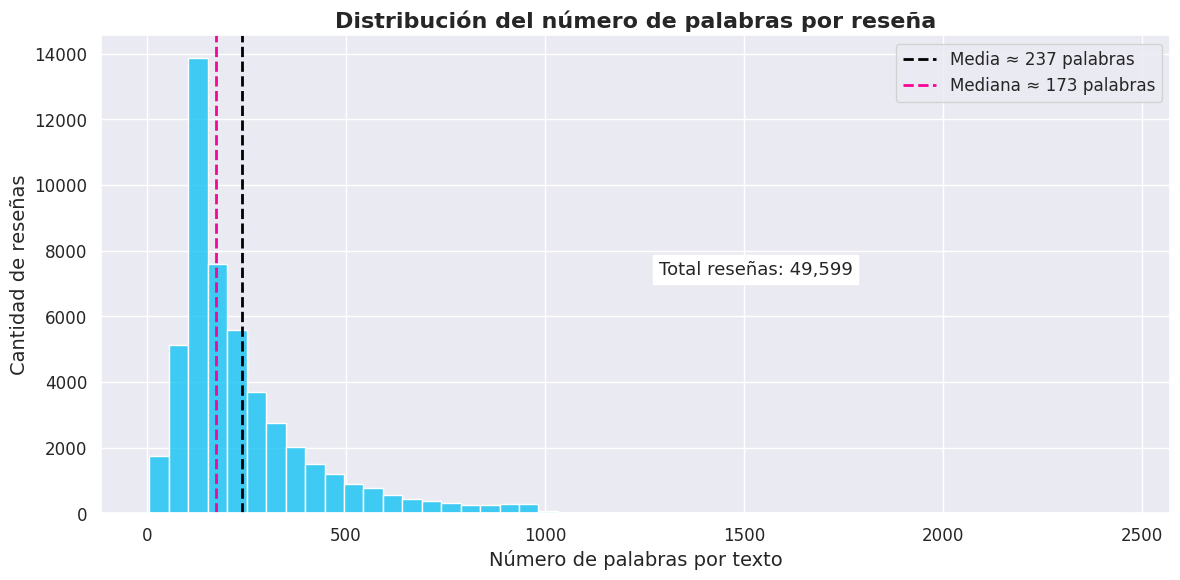

In [94]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

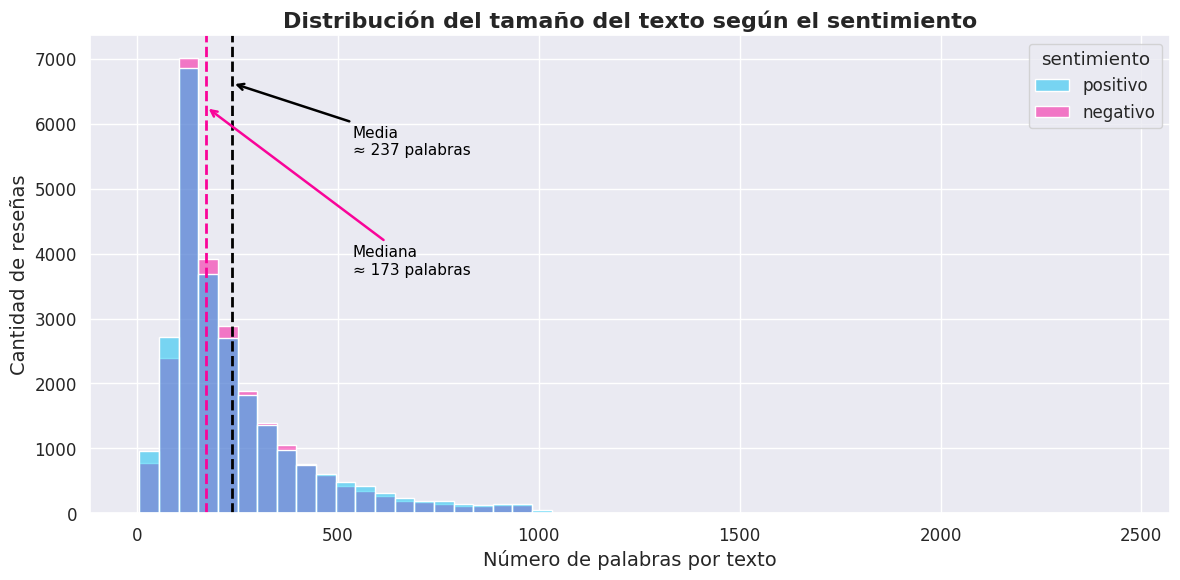

In [95]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

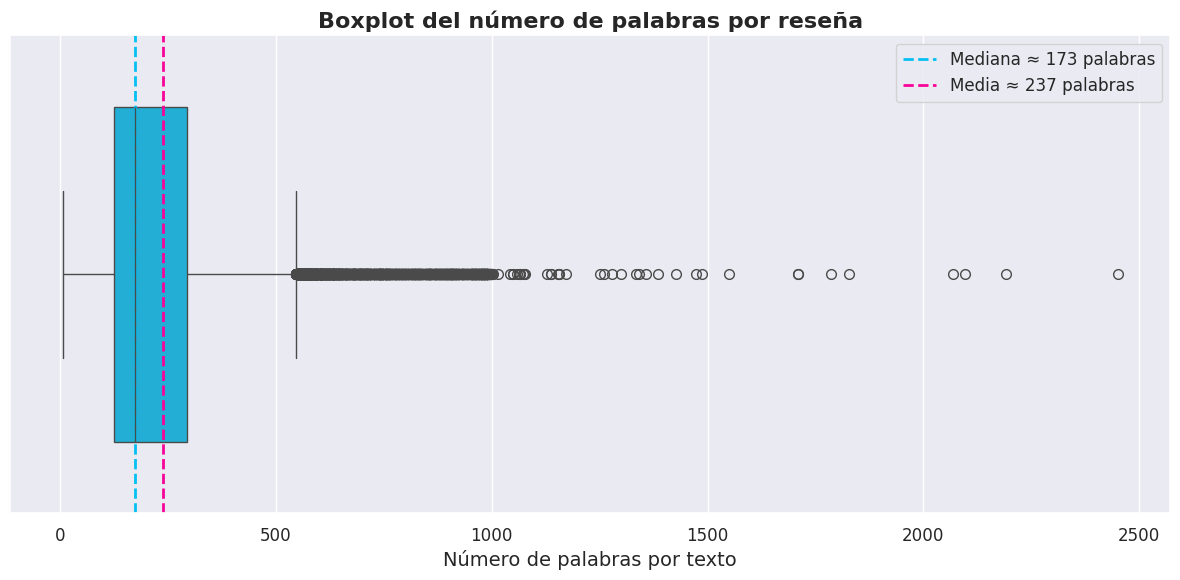

In [96]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

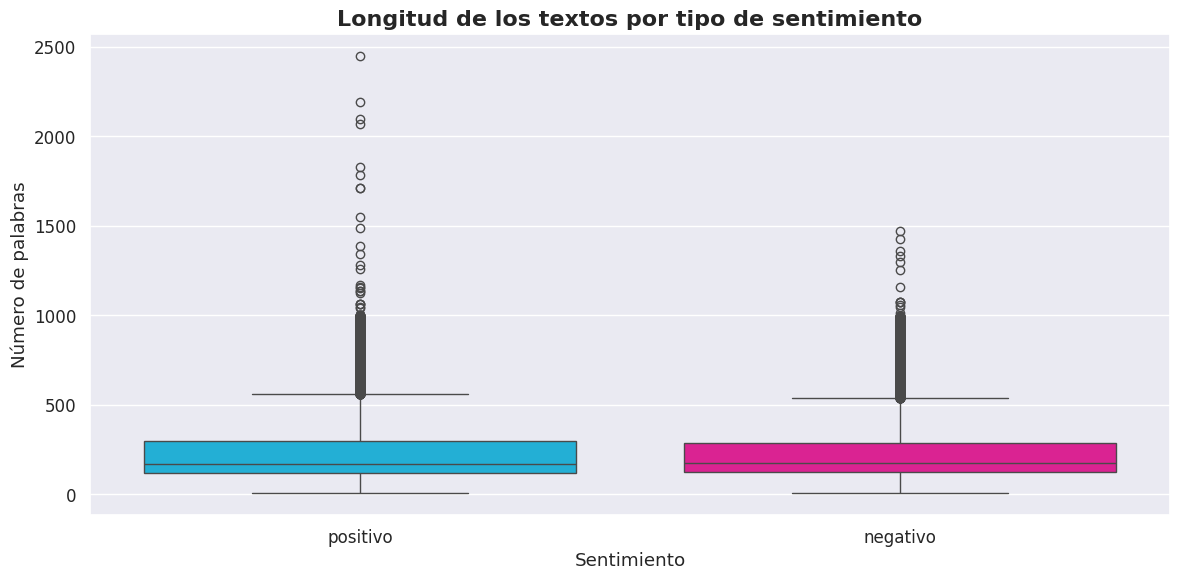

In [97]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [98]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [99]:
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "desconocido"

In [100]:
datos.shape

(49599, 3)

In [101]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [102]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [103]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1816 filas que no estaban en español


In [104]:
datos = datos_limpios

In [105]:
datos.shape

(47783, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [106]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23848


In [107]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23848.0  227.798390  157.361661   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [108]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [109]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 87 reseñas positivas extras


In [110]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23848

In [111]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [112]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [113]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23848
negativo,23848


In [114]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%     75%  \
sentimiento                                                                
negativo     23848.0  227.798390  157.361661   6.0  125.0  172.0  284.00   
positivo     23848.0  228.215951  161.739488  10.0  121.0  169.0  288.25   

               max  
sentimiento         
negativo     998.0  
positivo     882.0  


#### Estandarización a minúsculas

In [115]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,¡En total contraste con las opiniones de la ot...,positivo,142,es
1,¿No hay nadie más cansado de ese viejo cliché ...,negativo,775,es
2,Si el escritor / director está leyendo esto (y...,negativo,89,es
3,Después de ver la revuelta de los zombies prot...,negativo,274,es
4,"Un novelista francés, disgustado por las amiga...",positivo,532,es
...,...,...,...,...
47691,"""Pecker"" demuestra que las aguas no tienen int...",positivo,179,es
47692,Playmania es extremadamente aburrido.Esta es l...,negativo,157,es
47693,"Un amigo mío, que es aún más en las películas ...",negativo,205,es
47694,"Admito que nunca he visto ""Esperando a Gfffman...",positivo,636,es


In [116]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [117]:
datos['review_es_limpio']

,review_es_limpio
0,¡en total contraste con las opiniones de la ot...
1,¿no hay nadie más cansado de ese viejo cliché ...
2,si el escritor / director está leyendo esto (y...
3,después de ver la revuelta de los zombies prot...
4,"un novelista francés, disgustado por las amiga..."
...,...
47691,"""pecker"" demuestra que las aguas no tienen int..."
47692,playmania es extremadamente aburrido.esta es l...
47693,"un amigo mío, que es aún más en las películas ..."
47694,"admito que nunca he visto ""esperando a gfffman..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [118]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [119]:
display(datos['review_es_limpio'])

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y m...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gfffman ...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [147]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [148]:
display(datos['review_es_limpio'])

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y me...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gfffman ...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [149]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,¡En total contraste con las opiniones de la ot...,positivo,142,es,en total contraste con las opiniones de la otr...
1,¿No hay nadie más cansado de ese viejo cliché ...,negativo,775,es,no hay nadie más cansado de ese viejo cliché d...
2,Si el escritor / director está leyendo esto (y...,negativo,89,es,si el escritor director está leyendo esto y me...
3,Después de ver la revuelta de los zombies prot...,negativo,274,es,después de ver la revuelta de los zombies prot...
4,"Un novelista francés, disgustado por las amiga...",positivo,532,es,un novelista francés disgustado por las amigas...
...,...,...,...,...,...
47691,"""Pecker"" demuestra que las aguas no tienen int...",positivo,179,es,pecker demuestra que las aguas no tienen inten...
47692,Playmania es extremadamente aburrido.Esta es l...,negativo,157,es,playmania es extremadamente aburridoesta es la...
47693,"Un amigo mío, que es aún más en las películas ...",negativo,205,es,un amigo mío que es aún más en las películas d...
47694,"Admito que nunca he visto ""Esperando a Gfffman...",positivo,636,es,admito que nunca he visto esperando a gfffman ...


### **Definición de variables de entrada (X) y salida (y)**

In [150]:
X = datos['review_es_limpio']

In [151]:
display(X)

,review_es_limpio
0,en total contraste con las opiniones de la otr...
1,no hay nadie más cansado de ese viejo cliché d...
2,si el escritor director está leyendo esto y me...
3,después de ver la revuelta de los zombies prot...
4,un novelista francés disgustado por las amigas...
...,...
47691,pecker demuestra que las aguas no tienen inten...
47692,playmania es extremadamente aburridoesta es la...
47693,un amigo mío que es aún más en las películas d...
47694,admito que nunca he visto esperando a gfffman ...


In [152]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [153]:
display(y)

,sentimiento
0,1
1,0
2,0
3,0
4,1
...,...
47691,1
47692,0
47693,0
47694,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [155]:
stopwords_es = stopwords.words('spanish')

In [156]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_es,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [157]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [158]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2518796 stored elements and shape (33387, 5000)>

### **Transformación del conjunto de prueba**

In [159]:
X_test_tfidf = vectorizador.transform(X_test)

In [160]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1087044 stored elements and shape (14309, 5000)>

#### Dimension

In [161]:
X_train_tfidf.shape

(33387, 5000)

In [162]:
X_test_tfidf.shape

(14309, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [163]:
modelo = LogisticRegression(random_state=42)

#### Entrenamiento del modelo

In [164]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(random_state=42)

#### Predicciones

In [165]:
y_pred = modelo.predict(X_test_tfidf)

In [166]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [167]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.89      0.86      0.87      7222
    positivo       0.86      0.89      0.87      7087

    accuracy                           0.87     14309
   macro avg       0.87      0.87      0.87     14309
weighted avg       0.87      0.87      0.87     14309



#### Obtener palabras más significativas para cada sentimiento

In [172]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [173]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


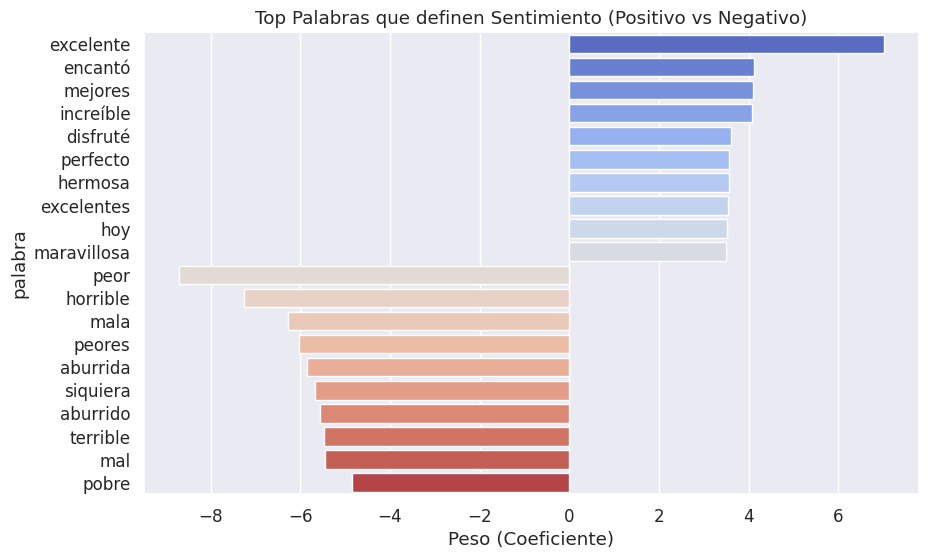

In [174]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el BackEnd pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.1.joblib')

['sentiment_model_1.1.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.68


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

In [ ]:
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}


**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

In [ ]:
# Arhivo txt, requirements.txt
# Dentro del archivo .txt el siguiente texto:

fastapi
uvicorn
joblib
scikit-learn
nltk
numpy

In [ ]:
# Arhivo py, app.py
# Dentro del archivo .py el siguiente codigo:

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np
import os

# Definición de la app
app = FastAPI(title="Sentiment Analysis API")

# Cargar el modelo

MODEL_PATH = "sentiment_model.joblib" # O "sentiment_model_1.1.joblib"

if not os.path.exists(MODEL_PATH):
    raise Exception(f"No se encontró el archivo del modelo en: {MODEL_PATH}")

modelo = joblib.load(MODEL_PATH)

class SentimentRequest(BaseModel):
    text: str

class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):
    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento."
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

In [ ]:
# Arhivo ipynb, Modelo_hackathon.ipynb
# El archivo .ipynb crea el archivo (sentiment_model.joblib)
# Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload